In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
import os

In [149]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /home/pratham/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/pratham/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/pratham/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [150]:
data = pd.read_csv('data/BA_reviews.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head(5)

,reviews
0,✅ Trip Verified | I had an appalling experie...
1,"Not Verified | Good points, the cabin crew, t..."
2,"Not Verified | It was a decent flight, reason..."
3,✅ Trip Verified | I really like flying Briti...
4,✅ Trip Verified | Could not book online the ...


In [151]:
def clean_reviews(df):
    df_clean = df.copy()
    df_clean['verified'] = df_clean['reviews'].apply(lambda x: 1 if "✅ Trip Verified" in x or "✅ Verified Review" in x else 0)
    df_clean['clean_review'] = df_clean['reviews'].apply(
        lambda x: re.sub(r'✅ Trip Verified \| |✅ Verified Review \| |Not Verified \| ', '', x)
    )
    return df_clean
data_clean = clean_reviews(data)
data_clean

,reviews,verified,clean_review
0,✅ Trip Verified | I had an appalling experie...,1,I had an appalling experience with British A...
1,"Not Verified | Good points, the cabin crew, t...",0,"Good points, the cabin crew, they were helpfu..."
2,"Not Verified | It was a decent flight, reason...",0,"It was a decent flight, reasonable comfortabl..."
3,✅ Trip Verified | I really like flying Briti...,1,I really like flying British Airways particu...
4,✅ Trip Verified | Could not book online the ...,1,✅ Trip Verified | Could not book online the ...
...,...,...,...
3932,Flew LHR - VIE return operated by bmi but BA a...,0,Flew LHR - VIE return operated by bmi but BA a...
3933,LHR to HAM. Purser addresses all club passenge...,0,LHR to HAM. Purser addresses all club passenge...
3934,My son who had worked for British Airways urge...,0,My son who had worked for British Airways urge...
3935,London City-New York JFK via Shannon on A318 b...,0,London City-New York JFK via Shannon on A318 b...


In [152]:
def sentiment_analysis(text):
    SIA = SentimentIntensityAnalyzer()
    sentiment = SIA.polarity_scores(text)
    if sentiment["compound"] >= 0.05:
        return "positive"
    elif sentiment["compound"] <= -0.05:
        return "negative"
    else:
        return "neutral"

In [153]:
data_clean['sentiment'] = data_clean['clean_review'].apply(sentiment_analysis)
data_clean["sentiment_score"] = data_clean["clean_review"].apply(
    lambda x: SentimentIntensityAnalyzer().polarity_scores(x)["compound"]
)
sentiment_counts = data_clean['sentiment'].value_counts(normalize=True) * 100
print("\nSentiment Distribution:")
print(sentiment_counts)


Sentiment Distribution:
sentiment
positive    57.150114
negative    41.503683
neutral      1.346203
Name: proportion, dtype: float64


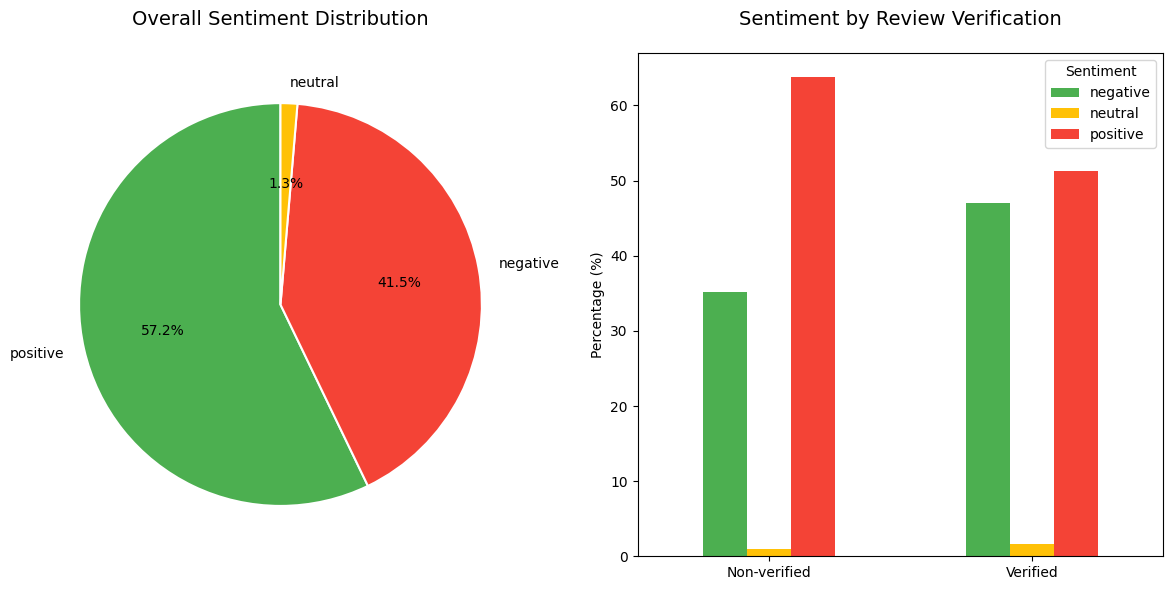

In [154]:
# Create Figure 1: Sentiment Distribution
plt.figure(figsize=(12, 6))

# Pie chart
plt.subplot(1, 2, 1)
colors_map = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FFC107'}
sentiment_counts.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=[colors_map[x] for x in sentiment_counts.index],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Overall Sentiment Distribution', fontsize=14, pad=20)
plt.ylabel('')

# Bar chart - Verified vs Non-verified
plt.subplot(1, 2, 2)
verified_sentiment = pd.crosstab(
    data_clean['verified'], data_clean['sentiment'], 
    normalize='index'
) * 100

verified_sentiment.rename(index={1: 'Verified', 0: 'Non-verified'}, inplace=True)
verified_sentiment.plot(
    kind='bar',
    color=[colors_map['positive'], colors_map['neutral'], colors_map['negative']],
    ax=plt.gca()  # Use the current axis
)
plt.title('Sentiment by Review Verification', fontsize=14, pad=20)
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')

plt.tight_layout()
plt.savefig('visuals/sentiment_distribution.png', dpi=300, bbox_inches='tight')

# Display the plots
plt.show()

In [155]:
def extract_topics(text, topic_keywords):
    text_lower = text.lower()
    topics_found = []
    for topic, keywords in topic_keywords.items():
        if any(keyword in text_lower for keyword in keywords):
            topics_found.append(topic)
    
    return topics_found

In [156]:
# Define topic keywords
topic_keywords = {
    'Staff/Service': ['staff', 'crew', 'service', 'attendant', 'customer service'],
    'Seat Comfort': ['seat', 'legroom', 'space', 'cramped', 'comfortable', 'uncomfortable'],
    'Food Quality': ['food', 'meal', 'catering', 'drink', 'beverage', 'snack'],
    'Punctuality': ['delay', 'delayed', 'late', 'wait', 'waiting', 'on time', 'punctual'],
    'Cleanliness': ['clean', 'cleanliness', 'dirty', 'hygiene', 'tidy'],
    'Entertainment': ['entertainment', 'movie', 'film', 'music', 'wifi', 'internet'],
    'Baggage': ['baggage', 'luggage', 'suitcase', 'bag', 'lost'],
    'Booking': ['booking', 'reservation', 'check-in', 'website', 'app'],
    'Value': ['price', 'value', 'expensive', 'cost', 'cheap', 'worth'],
    'Lounge': ['lounge', 'club', 'priority']
}

# Apply topic extraction
data_clean['topics'] = data_clean['clean_review'].apply(
    lambda x: extract_topics(x, topic_keywords)
)

# Explode topics to analyze them individually
topics_df = data_clean.explode('topics').dropna(subset=['topics'])

# Topic frequency analysis
topic_counts = topics_df['topics'].value_counts().reset_index()
topic_counts.columns = ['Topic', 'Count']
topic_counts['Percentage'] = (topic_counts['Count'] / len(data_clean) * 100).round(1)

print("\nTopic Frequency Analysis:")
print(topic_counts)


Topic Frequency Analysis:
           Topic  Count  Percentage
0  Staff/Service   3171        80.5
1   Food Quality   2514        63.9
2   Seat Comfort   2469        62.7
3    Punctuality   1922        48.8
4        Booking   1723        43.8
5         Lounge   1206        30.6
6          Value   1177        29.9
7        Baggage   1150        29.2
8  Entertainment    816        20.7
9    Cleanliness    474        12.0


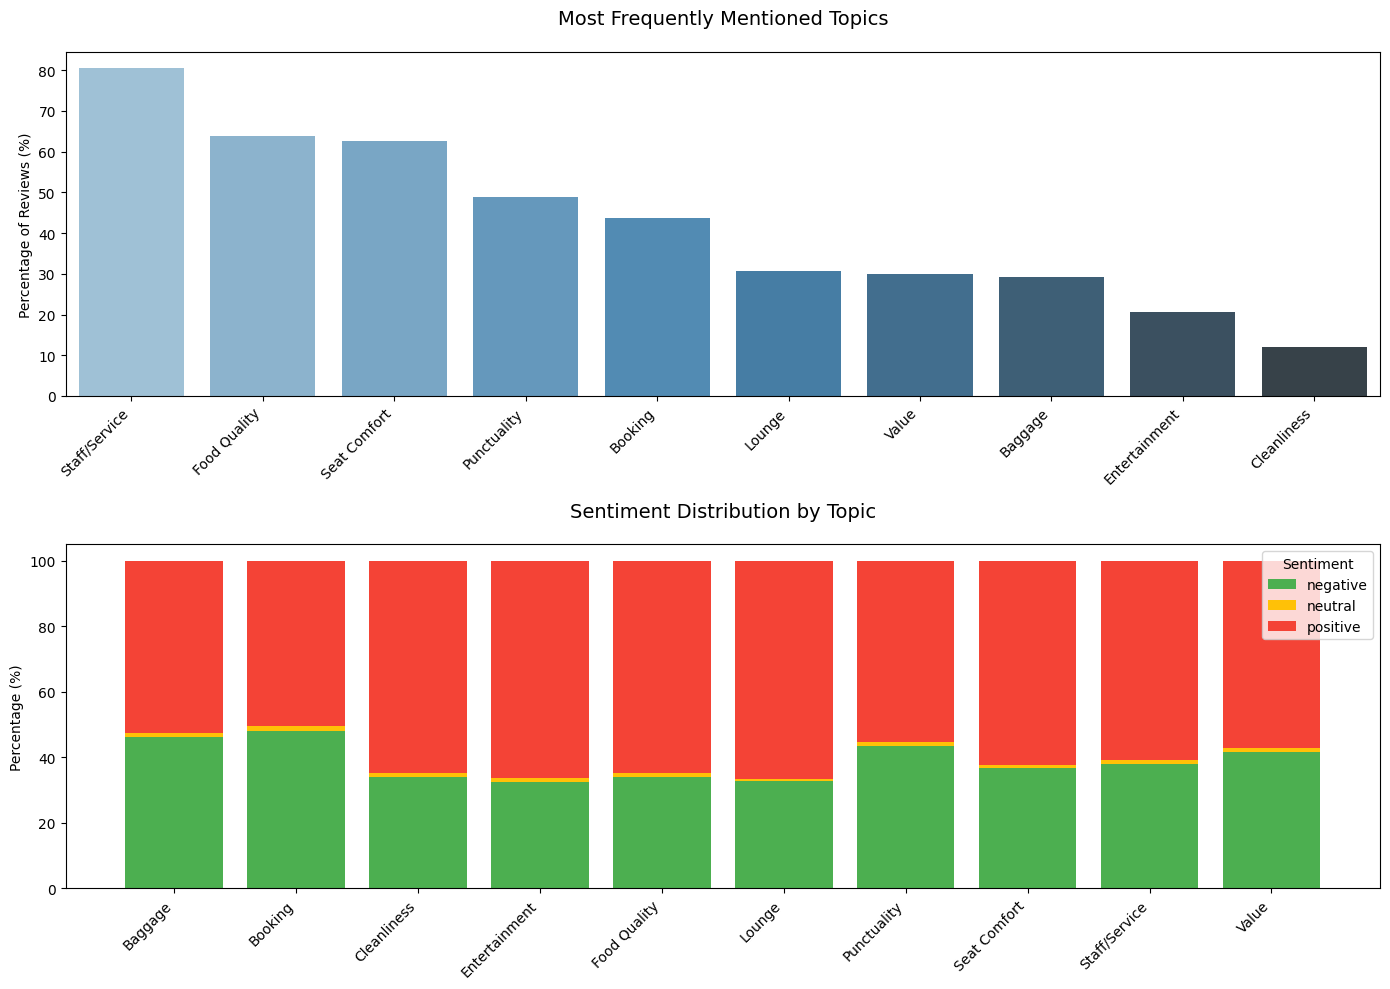

In [157]:
# Create Figure 2: Topic Analysis
plt.figure(figsize=(14, 10))

# Topic frequency
plt.subplot(2, 1, 1)
sns.barplot(
    x='Topic', 
    y='Percentage', 
    data=topic_counts.sort_values('Percentage', ascending=False),
    palette='Blues_d'
)
plt.title('Most Frequently Mentioned Topics', fontsize=14, pad=20)
plt.ylabel('Percentage of Reviews (%)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Topic sentiment analysis
plt.subplot(2, 1, 2)
topic_sentiment = pd.crosstab(
    topics_df['topics'], topics_df['sentiment'],
    normalize='index'
) * 100

# Explicitly plot the stacked bar chart
bottom = np.zeros(len(topic_sentiment))
colors = [colors_map['positive'], colors_map['neutral'], colors_map['negative']]
for sentiment, color in zip(topic_sentiment.columns, colors):
    plt.bar(
        topic_sentiment.index,
        topic_sentiment[sentiment],
        bottom=bottom,
        color=color,
        label=sentiment
    )
    bottom += topic_sentiment[sentiment]

plt.title('Sentiment Distribution by Topic', fontsize=14, pad=20)
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.savefig('visuals/topic_analysis.png', dpi=300, bbox_inches='tight')

# Display the plots
plt.show()

In [158]:
def create_wordcloud(text_series, title, filename, sentiment=None):
    stop_words = set(stopwords.words('english'))
    additional_stopwords = {'british', 'airways', 'ba', 'flight', 'airline', 'would', 
                          'one', 'us', 'get', 'also', 'even', 'could', 'trip', 
                          'verified', 'review', 'london', 'heathrow'}
    stop_words.update(additional_stopwords)
    if sentiment:
        text_series = data_clean[data_clean['sentiment'] == sentiment]['clean_review']
    text = ' '.join(text_series)
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='black', 
        max_words=100,
        contour_width=1,
        contour_color='steelblue', 
        stopwords=stop_words,
        colormap='Blues'
    ).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig('visuals/' + filename, dpi=300, bbox_inches='tight')
    plt.close()

In [159]:
create_wordcloud(data_clean['clean_review'], 'All Reviews WordCloud', 'all_reviews_wordcloud.png')
create_wordcloud(data_clean['clean_review'], 'Positive Reviews WordCloud', 'positive_reviews_wordcloud.png', 'positive')
create_wordcloud(data_clean['clean_review'], 'Negative Reviews WordCloud', 'negative_reviews_wordcloud.png', 'negative')

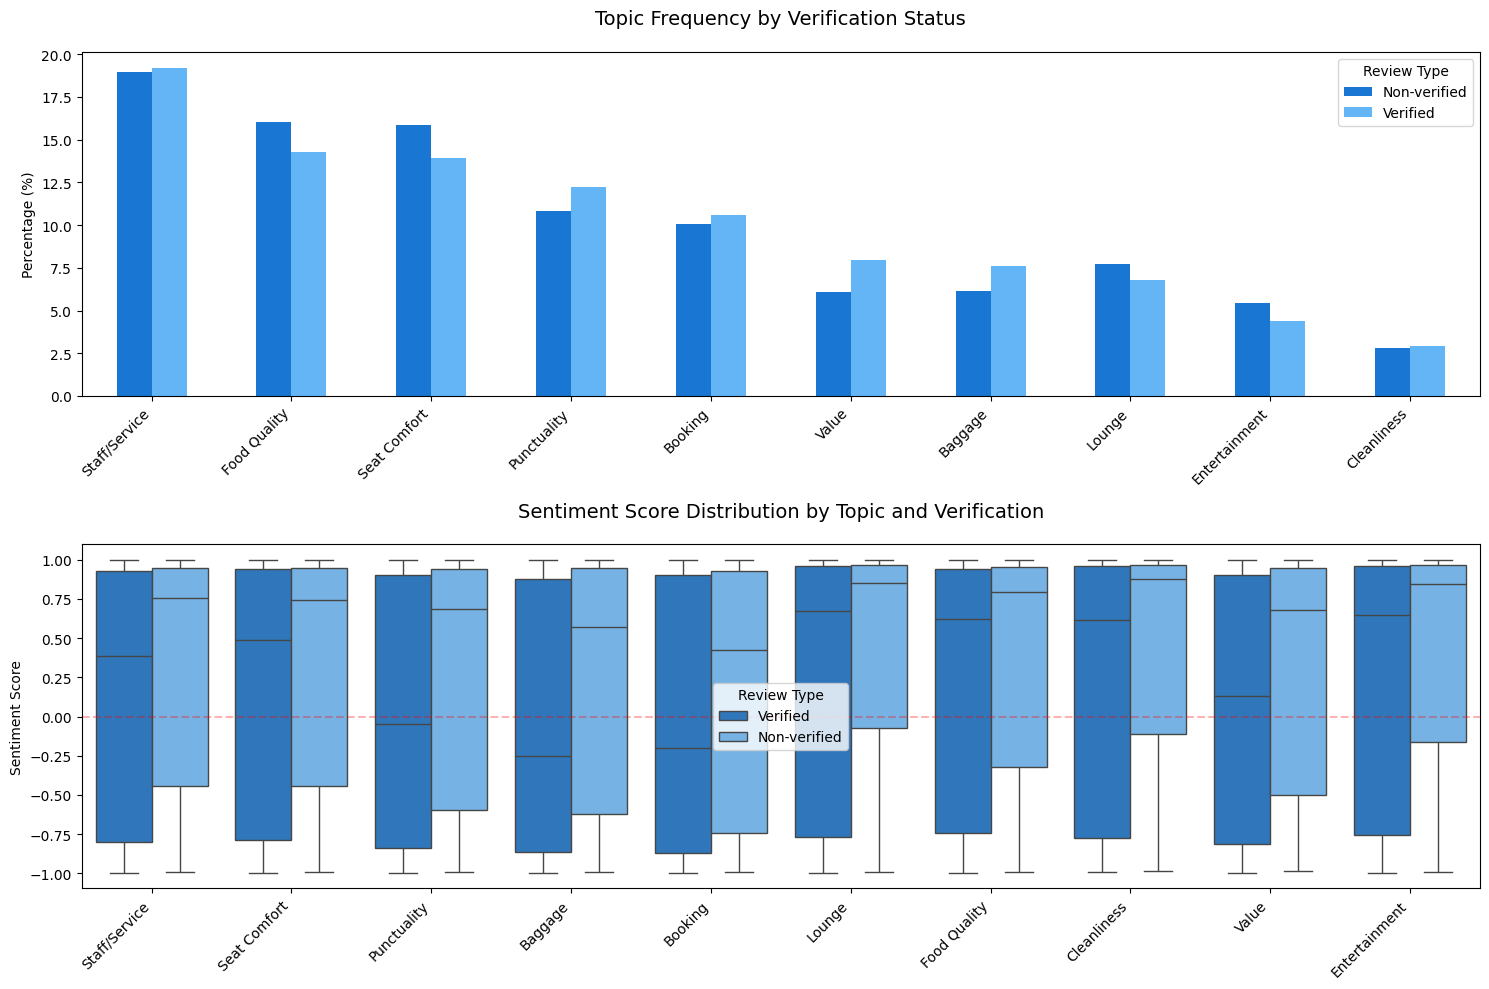

In [160]:
# Create Figure 4: Verified vs Non-verified Comparison
# ...existing code...
plt.figure(figsize=(15, 10))

# Topic frequency by verification status
topic_verification = pd.crosstab(
    topics_df['topics'], topics_df['verified'],
    normalize='columns'
) * 100
topic_verification.rename(columns={1: 'Verified', 0: 'Non-verified'}, inplace=True)

# Use matplotlib's bar for subplot
ax1 = plt.subplot(2, 1, 1)
topic_verification.sort_values('Verified', ascending=False).plot(
    kind='bar',
    color=['#1976D2', '#64B5F6'],
    ax=ax1
)
plt.title('Topic Frequency by Verification Status', fontsize=14, pad=20)
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Review Type')

# Sentiment score distribution by verification status
plt.subplot(2, 1, 2)
sns.boxplot(
    x='topics', 
    y='sentiment_score', 
    hue='verified',
    data=topics_df.replace({'verified': {1: 'Verified', 0: 'Non-verified'}}),
    palette=['#1976D2', '#64B5F6']
)
plt.title('Sentiment Score Distribution by Topic and Verification', fontsize=14, pad=20)
plt.ylabel('Sentiment Score')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Review Type')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('visuals/verified_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

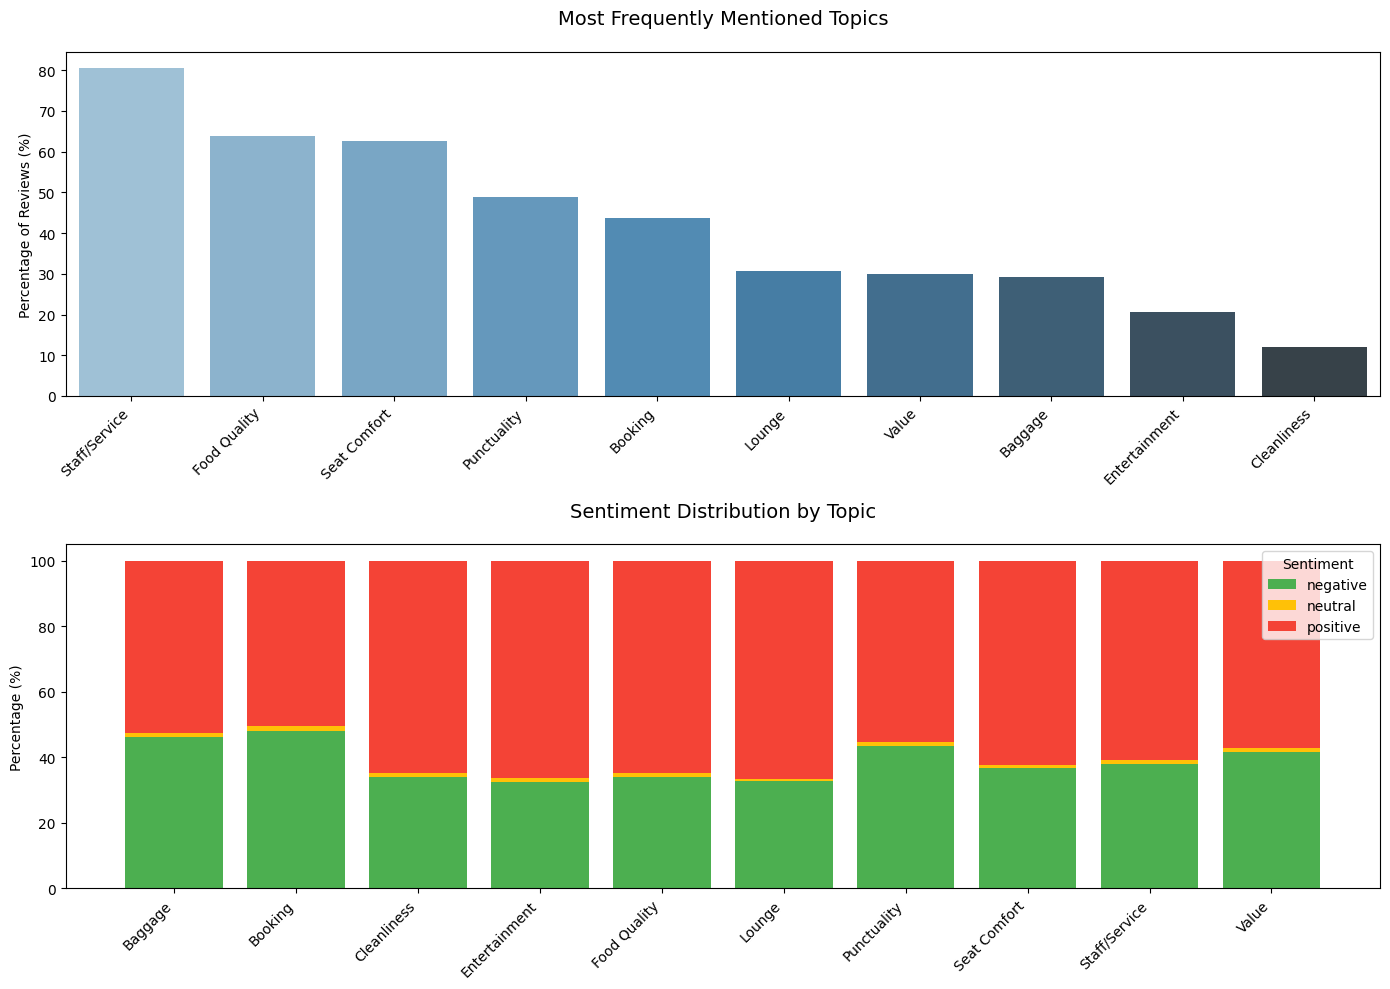

In [161]:
# Create Figure 5: Key Problematic Aspects
# Identify most negative topics
plt.figure(figsize=(14, 10))

# Topic frequency
ax1 = plt.subplot(2, 1, 1)
sns.barplot(
    x='Topic', 
    y='Percentage', 
    data=topic_counts.sort_values('Percentage', ascending=False),
    palette='Blues_d',
    ax=ax1
)
plt.title('Most Frequently Mentioned Topics', fontsize=14, pad=20)
plt.ylabel('Percentage of Reviews (%)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Topic sentiment analysis
plt.subplot(2, 1, 2)
topic_sentiment = pd.crosstab(
    topics_df['topics'], topics_df['sentiment'],
    normalize='index'
) * 100

bottom = np.zeros(len(topic_sentiment))
colors = [colors_map['positive'], colors_map['neutral'], colors_map['negative']]
for sentiment, color in zip(topic_sentiment.columns, colors):
    plt.bar(
        topic_sentiment.index,
        topic_sentiment[sentiment],
        bottom=bottom,
        color=color,
        label=sentiment
    )
    bottom += topic_sentiment[sentiment]

plt.title('Sentiment Distribution by Topic', fontsize=14, pad=20)
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.savefig('visuals/topic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [162]:
def extract_ngrams(text_series, n=2, top_n=15):
    # Preprocessing
    stop_words = set(stopwords.words('english'))
    
    # Initialize CountVectorizer for n-grams
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        stop_words=list(stop_words),
        max_features=top_n
    )
    
    # Fit and transform
    X = vectorizer.fit_transform(text_series)
    
    # Get feature names and counts
    ngrams = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    
    # Create DataFrame
    ngram_df = pd.DataFrame({'ngram': ngrams, 'count': counts})
    ngram_df = ngram_df.sort_values('count', ascending=False)
    
    return ngram_df

In [163]:
# Extract bigrams and trigrams
bigrams = extract_ngrams(data_clean['clean_review'], n=2, top_n=15)
trigrams = extract_ngrams(data_clean['clean_review'], n=3, top_n=15)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.barplot(x='count', y='ngram', data=bigrams, palette='Blues_d')
plt.title('Top 15 Bigrams (2-word phrases)', fontsize=14, pad=20)
plt.xlabel('Count')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.barplot(x='count', y='ngram', data=trigrams, palette='Blues_d')
plt.title('Top 15 Trigrams (3-word phrases)', fontsize=14, pad=20)
plt.xlabel('Count')
plt.ylabel('')

plt.tight_layout()
plt.savefig('visuals/common_phrases.png', dpi=300, bbox_inches='tight')
plt.close()
plt.show()

In [164]:
# Generate summary insights
print("\n=== SUMMARY INSIGHTS ===")
print(f"Total reviews analyzed: {len(data_clean)}")
print(f"Verified reviews: {data_clean['verified'].sum()} ({data_clean['verified'].mean()*100:.1f}%)")
print(f"Non-verified reviews: {len(data_clean) - data_clean['verified'].sum()} ({(1-data_clean['verified'].mean())*100:.1f}%)")
print("\nOverall Sentiment:")
for sentiment, percentage in sentiment_counts.items():
    print(f"- {sentiment.capitalize()}: {percentage:.1f}%")

print("\nTop 5 Most Mentioned Topics:")
for i, (topic, percentage) in enumerate(zip(topic_counts['Topic'].head(5), topic_counts['Percentage'].head(5))):
    print(f"{i+1}. {topic}: {percentage:.1f}% of reviews")

print("\nMost Problematic Aspects (Highest Negative %):")
for i, (topic, percentage) in enumerate(zip(top_negative_topics.index, top_negative_topics.values)):
    print(f"{i+1}. {topic}: {percentage:.1f}% negative")

# Generate insights about verified vs non-verified
verified_sentiment_pct = pd.crosstab(data_clean['verified'], data_clean['sentiment'], normalize='index') * 100
verified_sentiment_pct.rename(index={1: 'Verified', 0: 'Non-verified'}, inplace=True)

print("\nVerified vs Non-verified Sentiment Comparison:")
print(f"Verified reviews positive: {verified_sentiment_pct.loc['Verified', 'positive']:.1f}%")
print(f"Non-verified reviews positive: {verified_sentiment_pct.loc['Non-verified', 'positive']:.1f}%")
print(f"Verified reviews negative: {verified_sentiment_pct.loc['Verified', 'negative']:.1f}%")
print(f"Non-verified reviews negative: {verified_sentiment_pct.loc['Non-verified', 'negative']:.1f}%")

print("\nRecommendations based on analysis:")
print("1. Address punctuality issues and improve communication during delays")
print("2. Evaluate pricing strategy to better align with perceived value")
print("3. Standardize cleanliness protocols to ensure consistency")
print("4. Improve seat comfort and in-flight entertainment options")
print("5. Focus on verified customer feedback for targeted improvements")


=== SUMMARY INSIGHTS ===
Total reviews analyzed: 3937
Verified reviews: 2096 (53.2%)
Non-verified reviews: 1841 (46.8%)

Overall Sentiment:
- Positive: 57.2%
- Negative: 41.5%
- Neutral: 1.3%

Top 5 Most Mentioned Topics:
1. Staff/Service: 80.5% of reviews
2. Food Quality: 63.9% of reviews
3. Seat Comfort: 62.7% of reviews
4. Punctuality: 48.8% of reviews
5. Booking: 43.8% of reviews

Most Problematic Aspects (Highest Negative %):
1. Booking: 48.1% negative
2. Baggage: 46.3% negative
3. Punctuality: 43.5% negative
4. Value: 41.6% negative
5. Staff/Service: 38.0% negative

Verified vs Non-verified Sentiment Comparison:
Verified reviews positive: 51.3%
Non-verified reviews positive: 63.8%
Verified reviews negative: 47.0%
Non-verified reviews negative: 35.2%

Recommendations based on analysis:
1. Address punctuality issues and improve communication during delays
2. Evaluate pricing strategy to better align with perceived value
3. Standardize cleanliness protocols to ensure consistency
4.